In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load model & features
model = joblib.load('../models/best_model.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

# Load & preprocess data (same as modeling)
df = pd.read_csv('../data/icu_data.csv')
drop_cols = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id',
             'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
X = df_clean.drop('hospital_death', axis=1)
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())
X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

print("✅ Ready!")

✅ Ready!


In [2]:
explainer = shap.TreeExplainer(model)
# Sample 500 rows for speed
X_sample = X.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values calculated!")

✅ SHAP values calculated!


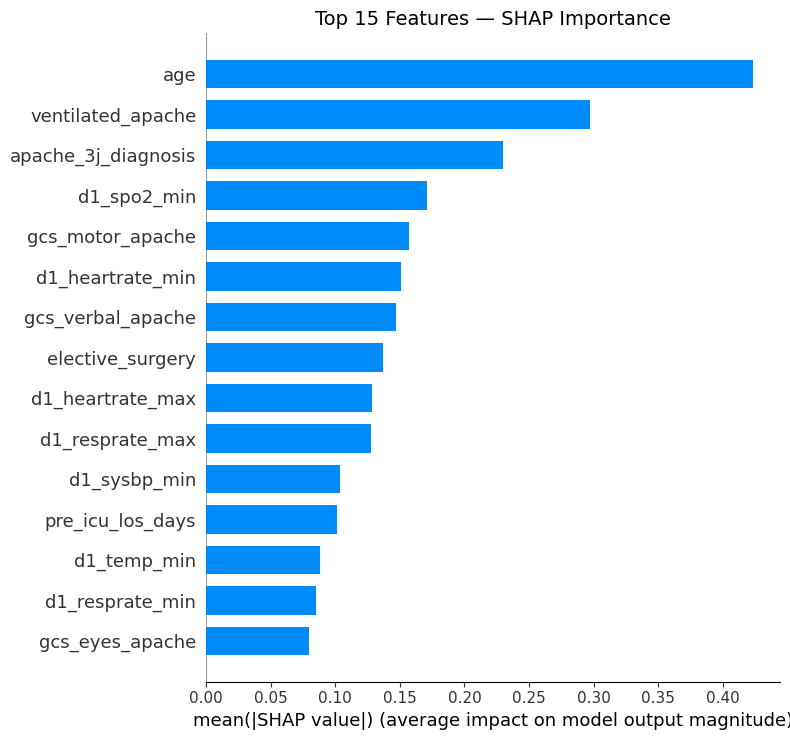

✅ Saved!


In [3]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", 
                  max_display=15, show=False)
plt.title("Top 15 Features — SHAP Importance", fontsize=14)
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

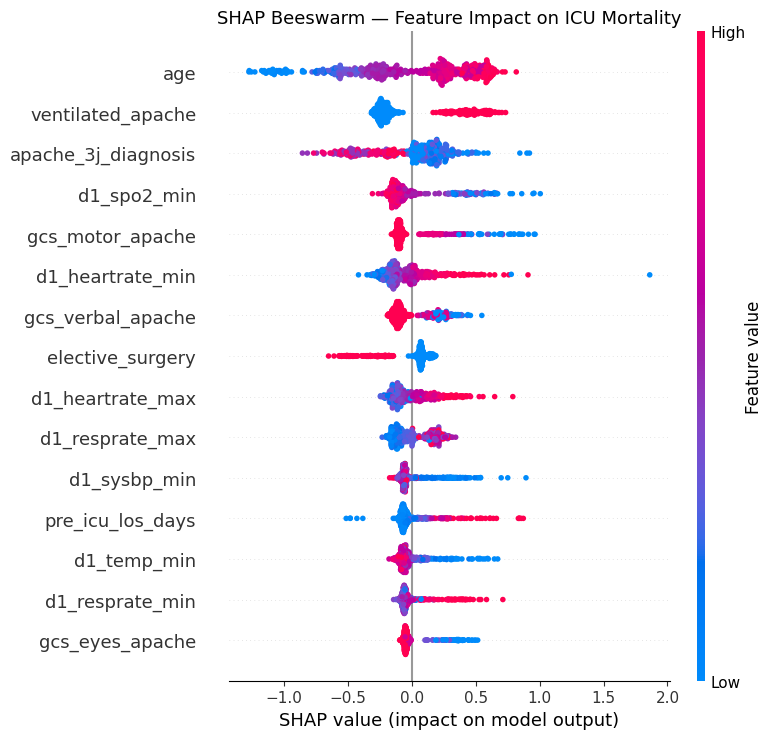

In [4]:
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title("SHAP Beeswarm — Feature Impact on ICU Mortality", fontsize=13)
plt.tight_layout()
plt.savefig('../models/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()